In [1]:
# E-commerce Sales & Traffic Analysis — Final Project

### Важливі посилання на матеріали проєкту:
### Інтерактивний Tableau Dashboard (2 сторінки): [Переглянути на Tableau Public](https://public.tableau.com/app/profile/mykyta.yemelianov3525/viz/Book1_17583094938840/UserTrafficDashboard?publish=yes)
### Повний GitHub-репозиторій проєкту:** [Переглянути на GitHub](https://github.com/mykytaggwp/portfolio_da)

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sql_query = """
SELECT 
    s.date AS session_date,
    s.ga_session_id,
    sp.continent,
    sp.country,
    sp.device AS device_type,
    sp.browser,
    sp.mobile_model_name AS device_model,
    sp.operating_system,
    sp.language AS browser_language,
    sp.medium AS traffic_source,
    sp.channel AS traffic_channel,
    a.id AS user_id,
    a.is_verified AS is_email_confirmed,
    a.is_unsubscribed,
    p.category AS product_category,
    p.name AS product_name,
    p.price,
    p.short_description AS product_description
FROM `data-analytics-mate.DA.session` AS s
LEFT JOIN `data-analytics-mate.DA.session_params` AS sp ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account_session` AS ans ON s.ga_session_id = ans.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` AS a ON ans.account_id = a.id
LEFT JOIN `data-analytics-mate.DA.order` AS o ON s.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` AS p ON o.item_id = p.item_id;
"""

df = pd.read_csv('portfolio_dataset.csv')

In [3]:
# ==========================================
# 2: Опис отриманого датасету
# ==========================================

In [4]:
df['session_date'] = pd.to_datetime(df['session_date'])

total_rows, total_cols = df.shape

datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

unique_sessions = df['ga_session_id'].nunique()
min_date = df['session_date'].min().strftime('%Y-%m-%d')
max_date = df['session_date'].max().strftime('%Y-%m-%d')

null_counts = df.isnull().sum()
null_pct = (null_counts / total_rows) * 100

null_summary = pd.DataFrame({
    'Колонка': null_counts.index,
    'Кількість пропусків': null_counts.values,
    'Відсоток пропусків (%)': null_pct.round(2).values
})
null_summary = null_summary[null_summary['Кількість пропусків'] > 0].reset_index(drop=True)

print(f"--- ЗАГАЛЬНИЙ ОГЛЯД ---")
print(f"Загальна кількість рядків: {total_rows}")
print(f"Загальна кількість колонок: {total_cols}\n")

print(f"--- РОЗПОДІЛ ЗА ТИПАМИ ДАНИХ ---")
print(f"Колонки типу datetime ({len(datetime_cols)}): {datetime_cols}")
print(f"Колонки числового типу ({len(numeric_cols)}): {numeric_cols}")
print(f"Колонки категоріального типу ({len(categorical_cols)}): {categorical_cols}\n")

print(f"--- МЕТРИКИ СЕСІЙ ТА ЧАСУ ---")
print(f"Кількість унікальних сесій: {unique_sessions}")
print(f"Часовий період: від {min_date} до {max_date}\n")

print("--- ПРОПУЩЕНІ ЗНАЧЕННЯ ---")
print(null_summary.to_string(index=False))

--- ЗАГАЛЬНИЙ ОГЛЯД ---
Загальна кількість рядків: 61712
Загальна кількість колонок: 18

--- РОЗПОДІЛ ЗА ТИПАМИ ДАНИХ ---
Колонки типу datetime (1): ['session_date']
Колонки числового типу (5): ['ga_session_id', 'user_id', 'is_email_confirmed', 'is_unsubscribed', 'price']
Колонки категоріального типу (12): ['continent', 'country', 'device_type', 'browser', 'device_model', 'operating_system', 'browser_language', 'traffic_source', 'traffic_channel', 'product_category', 'product_name', 'product_description']

--- МЕТРИКИ СЕСІЙ ТА ЧАСУ ---
Кількість унікальних сесій: 61712
Часовий період: від 2020-11-01 до 2020-11-19

--- ПРОПУЩЕНІ ЗНАЧЕННЯ ---
            Колонка  Кількість пропусків  Відсоток пропусків (%)
   browser_language                21101                   34.19
            user_id                56601                   91.72
 is_email_confirmed                56601                   91.72
    is_unsubscribed                56601                   91.72
   product_category       

In [5]:
# ==========================================
# КРОК 3.1: Географія продажів (Континенти та Країни)
# ==========================================

In [6]:
sales_by_continent = df.groupby('continent').agg(
    total_sales=('price', 'sum'),
    orders_count=('price', 'count')
).sort_values(by='total_sales', ascending=False).head(3)

sales_by_country = df.groupby('country').agg(
    total_sales=('price', 'sum'),
    orders_count=('price', 'count')
).sort_values(by='total_sales', ascending=False).head(5)

sales_by_continent['total_sales'] = sales_by_continent['total_sales'].map('{:,.2f} $'.format)
sales_by_country['total_sales'] = sales_by_country['total_sales'].map('{:,.2f} $'.format)

print("--- ТОП-3 КОНТИНЕНТИ ЗА ПРОДАЖАМИ ТА КІЛЬКІСТЮ ЗАМОВЛЕНЬ ---")
print(sales_by_continent.to_string())

print("\n--- ТОП-5 КРАЇН ЗА ПРОДАЖАМИ ТА КІЛЬКІСТЮ ЗАМОВЛЕНЬ ---")
print(sales_by_country.to_string())

--- ТОП-3 КОНТИНЕНТИ ЗА ПРОДАЖАМИ ТА КІЛЬКІСТЮ ЗАМОВЛЕНЬ ---
              total_sales  orders_count
continent                              
Americas   3,143,616.10 $          3370
Asia       1,475,886.70 $          1500
Europe     1,058,394.60 $          1116

--- ТОП-5 КРАЇН ЗА ПРОДАЖАМИ ТА КІЛЬКІСТЮ ЗАМОВЛЕНЬ ---
                   total_sales  orders_count
country                                     
United States   2,500,953.80 $          2654
India             511,949.40 $           562
Canada            405,453.90 $           463
United Kingdom    167,120.50 $           186
Spain             139,804.60 $           123


In [7]:
# ==========================================
# КРОК 3.2: Товарні категорії (Глобально та в країні-лідері)
# ==========================================

In [8]:
top10_global = df.groupby('product_category')['price'].sum().nlargest(10)

top_country = df.groupby('country')['price'].sum().idxmax()

top10_top_country = df[df['country'] == top_country].groupby('product_category')['price'].sum().nlargest(10)

category_comparison = pd.DataFrame({
    'Глобальні продажі ($)': top10_global.map('{:,.2f}'.format),
    f'Продажі у {top_country} ($)': top10_top_country.map('{:,.2f}'.format)
})

print("--- ТОП-10 КАТЕГОРІЙ ТОВАРІВ: ГЛОБАЛЬНО VS КРАЇНА-ЛІДЕР ---")
print(category_comparison.to_string())

--- ТОП-10 КАТЕГОРІЙ ТОВАРІВ: ГЛОБАЛЬНО VS КРАЇНА-ЛІДЕР ---
                                 Глобальні продажі ($) Продажі у United States ($)
product_category                                                                  
Sofas & armchairs                         1,685,121.50                  722,237.00
Chairs                                    1,057,428.60                  449,869.40
Beds                                        759,853.00                  347,430.50
Bookcases & shelving units                  700,090.90                  300,809.10
Cabinets & cupboards                        416,580.50                  182,652.50
Outdoor furniture                           411,595.40                  181,079.80
Tables & desks                              305,555.00                  128,023.00
Chests of drawers & drawer units            152,252.00                   60,492.50
Bar furniture                               149,370.00                   59,588.00
Children's furniture       

In [9]:
# ==========================================
# КРОК 3.3: Аналіз продажів за девайсами та трафіком
# ==========================================

In [10]:
total_revenue = df['price'].sum()

sales_by_device = (df.groupby('device_type')['price'].sum() / total_revenue * 100).round(2).reset_index()
sales_by_device.columns = ['Тип девайса', 'Частка продажів (%)']
sales_by_device = sales_by_device.sort_values(by='Частка продажів (%)', ascending=False)

sales_by_channel = (df.groupby('traffic_channel')['price'].sum() / total_revenue * 100).round(2).reset_index()
sales_by_channel.columns = ['Канал трафіку', 'Частка продажів (%)']
sales_by_channel = sales_by_channel.sort_values(by='Частка продажів (%)', ascending=False)

sales_by_source = (df.groupby('traffic_source')['price'].sum() / total_revenue * 100).round(2).reset_index()
sales_by_source.columns = ['Джерело трафіку', 'Частка продажів (%)']
sales_by_source = sales_by_source.sort_values(by='Частка продажів (%)', ascending=False).head(5)

print("--- ПРОДАЖІ ЗА ТИПАМИ ДЕВАЙСІВ (%) ---")
print(sales_by_device.to_string(index=False))

print("\n--- ПРОДАЖІ ЗА КАНАЛАМИ ТРАФІКУ (%) ---")
print(sales_by_channel.to_string(index=False))

print("\n--- ТОП-5 ДЖЕРЕЛ ТРАФІКУ ЗА ПРОДАЖАМИ (%) ---")
print(sales_by_source.to_string(index=False))

--- ПРОДАЖІ ЗА ТИПАМИ ДЕВАЙСІВ (%) ---
Тип девайса  Частка продажів (%)
    desktop                59.09
     mobile                38.84
     tablet                 2.07

--- ПРОДАЖІ ЗА КАНАЛАМИ ТРАФІКУ (%) ---
 Канал трафіку  Частка продажів (%)
Organic Search                33.91
   Paid Search                25.81
        Direct                24.14
 Social Search                 8.14
     Undefined                 8.00

--- ТОП-5 ДЖЕРЕЛ ТРАФІКУ ЗА ПРОДАЖАМИ (%) ---
Джерело трафіку  Частка продажів (%)
        organic                32.92
         (none)                24.14
       referral                17.14
        <Other>                13.70
 (data deleted)                 8.12


In [11]:
# ==========================================
# КРОК 3.4: Аналіз зареєстрованих користувачів та email-розсилки
# ==========================================

In [12]:
reg_df = df[df['user_id'].notnull()]

unique_users = reg_df.drop_duplicates(subset=['user_id'])
total_unique_users = len(unique_users)

pct_email_confirmed = (unique_users['is_email_confirmed'].mean() * 100).round(2)

pct_unsubscribed = (unique_users['is_unsubscribed'].mean() * 100).round(2)

behavior_comp = reg_df.groupby('is_unsubscribed').agg(
    total_sales=('price', 'sum'),
    orders_count=('price', 'count'),
    avg_order_value=('price', 'mean'),
    unique_users=('user_id', 'nunique')
).reset_index()

behavior_comp['is_unsubscribed'] = behavior_comp['is_unsubscribed'].map({0.0: 'Підписані', 1.0: 'Відписалися'})
behavior_comp['sales_per_user'] = (behavior_comp['total_sales'] / behavior_comp['unique_users']).round(2)

top5_reg_countries = unique_users['country'].value_counts().head(5).reset_index()
top5_reg_countries.columns = ['Країна', 'Кількість користувачів']

print(f"--- ЗАГАЛЬНА СТАТИСТИКА КОРИСТУВАЧІВ ---")
print(f"Усього унікальних зареєстрованих користувачів: {total_unique_users}")
print(f"Частка користувачів з підтвердженим email: {pct_email_confirmed}%")
print(f"Частка користувачів, які відписалися від розсилки: {pct_unsubscribed}%\n")

print("--- ПОРІВНЯННЯ ПОВЕДІНКИ ПІДПИСАНИХ ТА ВІДПИСАНИХ КОРИСТУВАЧІВ ---")
print(behavior_comp.to_string(index=False))

print("\n--- ТОП-5 КРАЇН ЗА КІЛЬКІСТЮ ЗАРЕЄСТРОВАНИХ КОРИСТУВАЧІВ ---")
print(top5_reg_countries.to_string(index=False))

--- ЗАГАЛЬНА СТАТИСТИКА КОРИСТУВАЧІВ ---
Усього унікальних зареєстрованих користувачів: 5111
Частка користувачів з підтвердженим email: 71.94%
Частка користувачів, які відписалися від розсилки: 17.12%

--- ПОРІВНЯННЯ ПОВЕДІНКИ ПІДПИСАНИХ ТА ВІДПИСАНИХ КОРИСТУВАЧІВ ---
is_unsubscribed  total_sales  orders_count  avg_order_value  unique_users  sales_per_user
      Підписані     397230.1           426       932.465023          4236           93.77
    Відписалися      86094.0            87       989.586207           875           98.39

--- ТОП-5 КРАЇН ЗА КІЛЬКІСТЮ ЗАРЕЄСТРОВАНИХ КОРИСТУВАЧІВ ---
        Країна  Кількість користувачів
 United States                    2281
         India                     483
        Canada                     375
United Kingdom                     156
         Spain                     105


In [13]:
# ==========================================
# КРОК 4.1: Загальна динаміка продажів та сезонність
# ==========================================

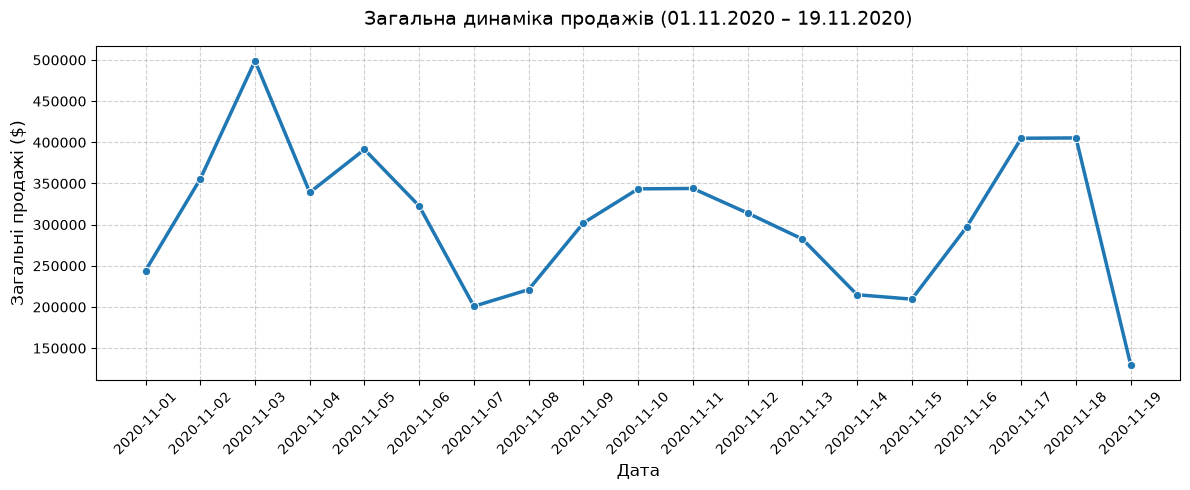

--- ЩОДЕННІ ПРОДАЖІ ТА ДНІ ТИЖНЯ ---
      Дата  Продажі ($) День тижня
2020-11-01 244,292.50 $     Sunday
2020-11-02 355,506.80 $     Monday
2020-11-03 498,979.60 $    Tuesday
2020-11-04 339,187.10 $  Wednesday
2020-11-05 391,276.60 $   Thursday
2020-11-06 322,642.20 $     Friday
2020-11-07 200,892.20 $   Saturday
2020-11-08 221,162.50 $     Sunday
2020-11-09 302,049.50 $     Monday
2020-11-10 343,471.80 $    Tuesday
2020-11-11 343,941.00 $  Wednesday
2020-11-12 314,070.10 $   Thursday
2020-11-13 282,575.40 $     Friday
2020-11-14 214,889.30 $   Saturday
2020-11-15 209,535.50 $     Sunday
2020-11-16 296,972.10 $     Monday
2020-11-17 404,954.60 $    Tuesday
2020-11-18 405,328.10 $  Wednesday
2020-11-19 129,500.00 $   Thursday


In [14]:
daily_sales = df.groupby('session_date')['price'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_sales, x='session_date', y='price', marker='o', color='#1f77b4', linewidth=2.5)

plt.title('Загальна динаміка продажів (01.11.2020 – 19.11.2020)', fontsize=14, pad=15)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Загальні продажі ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(daily_sales['session_date'], rotation=45)
plt.tight_layout()

plt.show()

daily_sales_display = daily_sales.copy()
daily_sales_display['session_date'] = daily_sales_display['session_date'].dt.strftime('%Y-%m-%d')
daily_sales_display['День тижня'] = daily_sales['session_date'].dt.day_name()
daily_sales_display['price'] = daily_sales_display['price'].map('{:,.2f} $'.format)
daily_sales_display.columns = ['Дата', 'Продажі ($)', 'День тижня']

print("--- ЩОДЕННІ ПРОДАЖІ ТА ДНІ ТИЖНЯ ---")
print(daily_sales_display.to_string(index=False))

In [15]:
# ==========================================
# КРОК 4.2: Динаміка продажів у розрізі континентів
# ==========================================

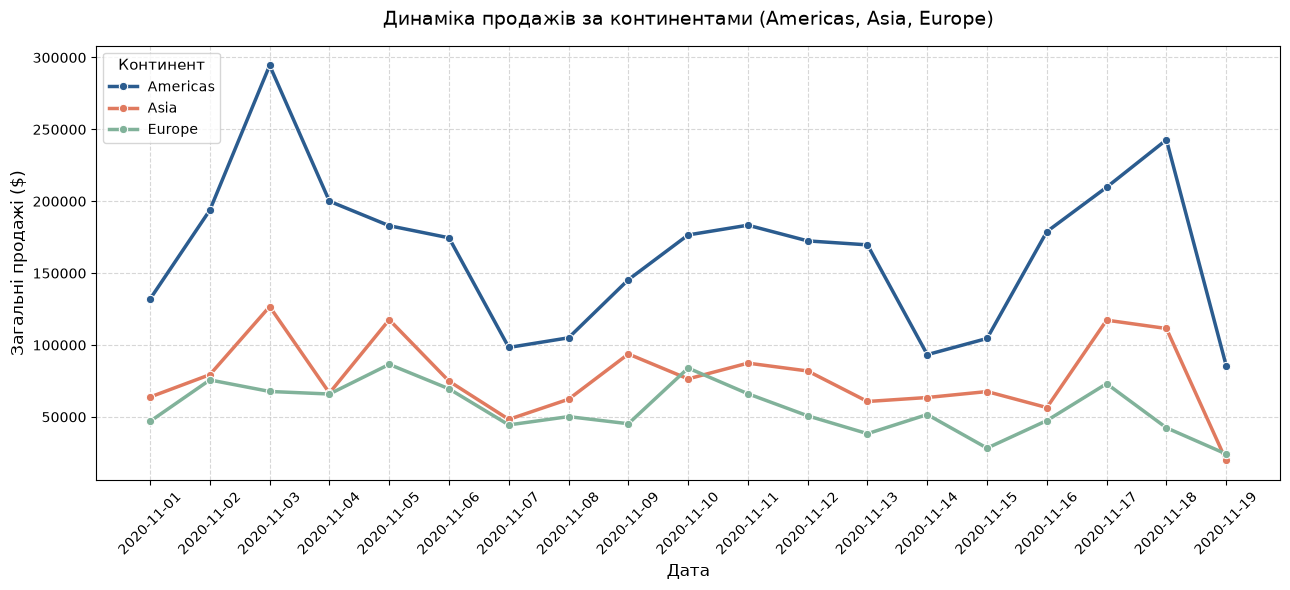

--- ПРОДАЖІ ЗА КОНТИНЕНТАМИ ПО ДНЯХ ---
continent         Americas          Asia       Europe
session_date                                         
2020-11-01    132,002.50 $   63,823.00 $  46,908.00 $
2020-11-02    193,861.00 $   79,370.00 $  75,710.80 $
2020-11-03    294,529.80 $  126,737.80 $  67,692.00 $
2020-11-04    200,009.50 $   66,602.00 $  65,915.00 $
2020-11-05    182,988.20 $  117,608.40 $  86,540.00 $
2020-11-06    174,571.40 $   74,841.20 $  69,527.60 $
2020-11-07     98,307.70 $   48,275.50 $  44,425.00 $
2020-11-08    105,017.00 $   62,288.50 $  50,193.00 $
2020-11-09    145,436.00 $   93,756.50 $  45,239.00 $
2020-11-10    176,573.00 $   76,448.80 $  83,969.00 $
2020-11-11    183,353.40 $   87,406.20 $  66,100.40 $
2020-11-12    172,430.10 $   81,940.00 $  50,749.00 $
2020-11-13    169,665.60 $   60,718.80 $  38,338.00 $
2020-11-14     93,308.90 $   63,491.00 $  51,649.00 $
2020-11-15    104,563.90 $   67,625.00 $  28,281.60 $
2020-11-16    178,897.60 $   56,496.00 $  

In [16]:
top_continents = ['Americas', 'Asia', 'Europe']
df_continents = df[df['continent'].isin(top_continents)]

continent_daily = df_continents.groupby(['session_date', 'continent'])['price'].sum().reset_index()

plt.figure(figsize=(13, 6))
palette = {'Americas': '#2b5c8f', 'Asia': '#e07a5f', 'Europe': '#81b29a'}

sns.lineplot(
    data=continent_daily, 
    x='session_date', 
    y='price', 
    hue='continent', 
    palette=palette, 
    linewidth=2.5, 
    marker='o'
)

plt.title('Динаміка продажів за континентами (Americas, Asia, Europe)', fontsize=14, pad=15)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Загальні продажі ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Континент', title_fontsize='11', fontsize='10')
plt.xticks(daily_sales['session_date'], rotation=45)
plt.tight_layout()

# Відображення графіка
plt.show()

# Звідна таблиця для аналізу даних
pivot_continents = continent_daily.pivot(index='session_date', columns='continent', values='price').fillna(0)
pivot_continents.index = pivot_continents.index.strftime('%Y-%m-%d')

# Універсальне форматування для будь-якої версії Pandas
pivot_continents_formatted = pivot_continents.apply(lambda col: col.map('{:,.2f} $'.format))

print("--- ПРОДАЖІ ЗА КОНТИНЕНТАМИ ПО ДНЯХ ---")
print(pivot_continents_formatted)

In [17]:
# ==========================================
# КРОК 4.3: Динаміка продажів у розрізі каналів трафіку
# ==========================================

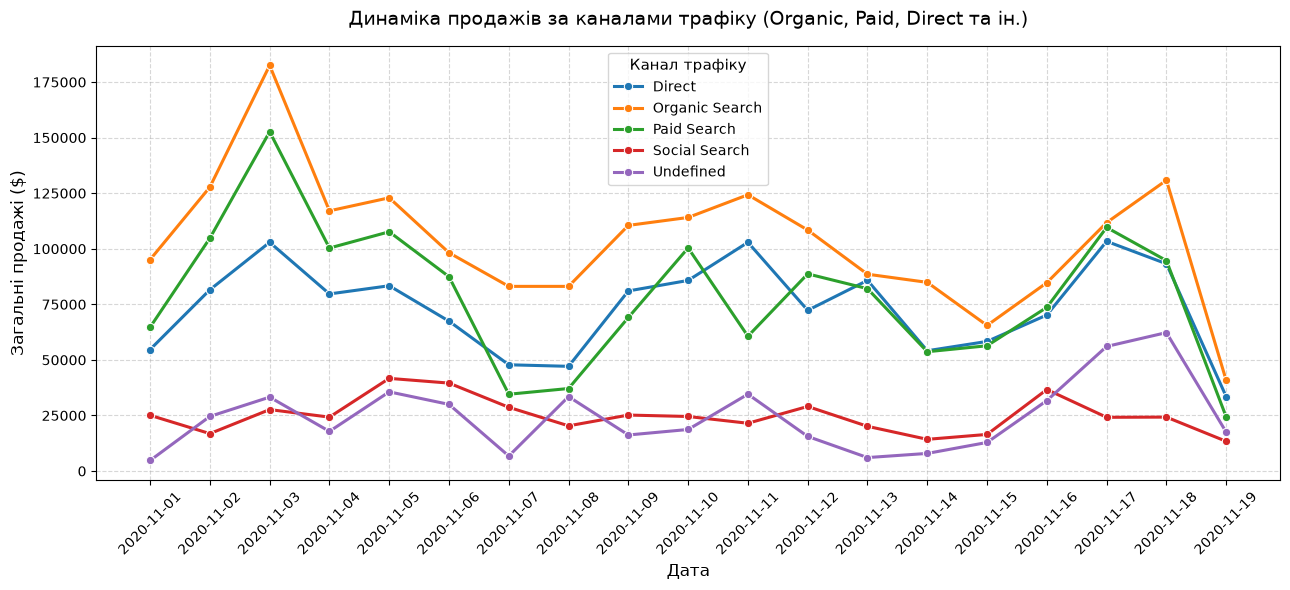

--- ПРОДАЖІ ЗА КАНАЛАМИ ТРАФІКУ ПО ДНЯХ ---
traffic_channel        Direct Organic Search   Paid Search Social Search  \
session_date                                                               
2020-11-01        54,669.50 $    95,112.00 $   64,688.00 $   25,078.00 $   
2020-11-02        81,561.50 $   127,746.50 $  104,780.80 $   16,843.00 $   
2020-11-03       102,909.50 $   182,521.90 $  152,641.30 $   27,652.50 $   
2020-11-04        79,683.60 $   117,067.10 $  100,332.00 $   24,257.40 $   
2020-11-05        83,367.60 $   122,938.40 $  107,648.00 $   41,693.20 $   
2020-11-06        67,434.70 $    98,208.10 $   87,438.40 $   39,572.00 $   
2020-11-07        47,808.00 $    83,084.70 $   34,553.50 $   28,681.00 $   
2020-11-08        47,114.00 $    83,086.50 $   37,135.00 $   20,338.00 $   
2020-11-09        81,032.00 $   110,521.50 $   69,085.00 $   25,187.00 $   
2020-11-10        85,754.40 $   114,088.00 $  100,383.80 $   24,547.60 $   
2020-11-11       102,906.00 $   124,300.70 $

In [18]:
channel_daily = df.groupby(['session_date', 'traffic_channel'])['price'].sum().reset_index()

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=channel_daily, 
    x='session_date', 
    y='price', 
    hue='traffic_channel', 
    linewidth=2.2, 
    marker='o'
)

plt.title('Динаміка продажів за каналами трафіку (Organic, Paid, Direct та ін.)', fontsize=14, pad=15)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Загальні продажі ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Канал трафіку', title_fontsize='11', fontsize='10')
plt.xticks(daily_sales['session_date'], rotation=45)
plt.tight_layout()

plt.show()

# 3. Звідна таблиця для аналізу
pivot_channels = channel_daily.pivot(index='session_date', columns='traffic_channel', values='price').fillna(0)
pivot_channels.index = pivot_channels.index.strftime('%Y-%m-%d')
pivot_channels_formatted = pivot_channels.apply(lambda col: col.map('{:,.2f} $'.format))

print("--- ПРОДАЖІ ЗА КАНАЛАМИ ТРАФІКУ ПО ДНЯХ ---")
print(pivot_channels_formatted)

In [19]:
# ==========================================
# КРОК 4.4: Динаміка продажів у розрізі типів девайсів
# ==========================================

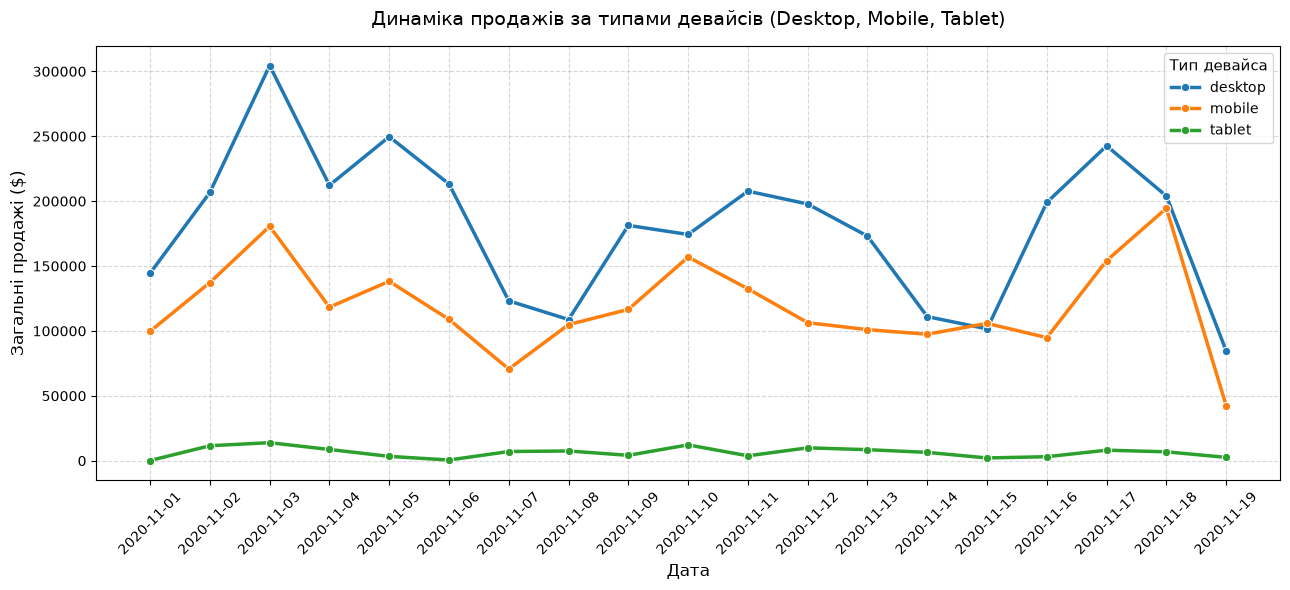

--- ПРОДАЖІ ЗА ТИПАМИ ДЕВАЙСІВ ПО ДНЯХ ---
device_type        desktop        mobile       tablet
session_date                                         
2020-11-01    144,445.00 $   99,698.50 $     149.00 $
2020-11-02    206,727.30 $  137,269.50 $  11,510.00 $
2020-11-03    304,473.80 $  180,602.80 $  13,903.00 $
2020-11-04    212,227.70 $  118,324.40 $   8,635.00 $
2020-11-05    249,682.00 $  138,256.00 $   3,338.60 $
2020-11-06    213,236.20 $  108,872.00 $     534.00 $
2020-11-07    123,175.20 $   70,651.00 $   7,066.00 $
2020-11-08    108,784.00 $  104,882.50 $   7,496.00 $
2020-11-09    181,327.00 $  116,583.50 $   4,139.00 $
2020-11-10    174,319.40 $  156,963.40 $  12,189.00 $
2020-11-11    207,703.90 $  132,474.60 $   3,762.50 $
2020-11-12    197,804.00 $  106,346.10 $   9,920.00 $
2020-11-13    173,073.20 $  101,000.20 $   8,502.00 $
2020-11-14    111,016.90 $   97,466.40 $   6,406.00 $
2020-11-15    101,604.60 $  105,812.40 $   2,118.50 $
2020-11-16    199,048.60 $   94,851.50 

In [20]:
device_daily = df.groupby(['session_date', 'device_type'])['price'].sum().reset_index()

plt.figure(figsize=(13, 6))
palette_device = {'desktop': '#1f77b4', 'mobile': '#ff7f0e', 'tablet': '#2ca02c'}

sns.lineplot(
    data=device_daily, 
    x='session_date', 
    y='price', 
    hue='device_type', 
    palette=palette_device,
    linewidth=2.5, 
    marker='o'
)

plt.title('Динаміка продажів за типами девайсів (Desktop, Mobile, Tablet)', fontsize=14, pad=15)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Загальні продажі ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Тип девайса', title_fontsize='11', fontsize='10')
plt.xticks(daily_sales['session_date'], rotation=45)
plt.tight_layout()

plt.show()

pivot_devices = device_daily.pivot(index='session_date', columns='device_type', values='price').fillna(0)
pivot_devices.index = pivot_devices.index.strftime('%Y-%m-%d')
pivot_devices_formatted = pivot_devices.apply(lambda col: col.map('{:,.2f} $'.format))

print("--- ПРОДАЖІ ЗА ТИПАМИ ДЕВАЙСІВ ПО ДНЯХ ---")
print(pivot_devices_formatted)

In [21]:
# ==========================================
# КРОК 5.1: Зведена таблиця: Сесії за каналами трафіку та девайсами
# ==========================================

In [22]:
df_filtered_sessions = df[
    (df['traffic_channel'].notnull()) & 
    (df['traffic_channel'] != 'Undefined') & 
    (df['device_type'].notnull()) & 
    (df['device_type'] != 'Undefined')
]

pivot_sessions = pd.pivot_table(
    df_filtered_sessions,
    index='traffic_channel',
    columns='device_type',
    values='ga_session_id',
    aggfunc='nunique',
    margins=True,
    margins_name='Всього'
)

pivot_sessions_formatted = pivot_sessions.apply(lambda col: col.map('{:,.0f}'.format))

print("--- ЗВЕДЕНА ТАБЛИЦЯ: КІЛЬКІСТЬ СЕСІЙ ЗА КАНАЛАМИ ТРАФІКУ ТА ДЕВАЙСАМИ ---")
print(pivot_sessions_formatted)

--- ЗВЕДЕНА ТАБЛИЦЯ: КІЛЬКІСТЬ СЕСІЙ ЗА КАНАЛАМИ ТРАФІКУ ТА ДЕВАЙСАМИ ---
device_type     desktop  mobile tablet  Всього
traffic_channel                               
Direct            8,340   5,660    290  14,290
Organic Search   12,410   8,405    482  21,297
Paid Search       9,406   6,371    374  16,151
Social Search     3,156   2,121    134   5,411
Всього           33,312  22,557  1,280  57,149


In [23]:
# ==========================================
# КРОК 5.2: Зведена таблиця: Продажі Топ-10 категорій у Топ-5 країнах
# ==========================================

In [24]:
top5_countries = df.groupby('country')['price'].sum().nlargest(5).index.tolist()
top10_categories = df.groupby('product_category')['price'].sum().nlargest(10).index.tolist()

df_top_sales = df[df['country'].isin(top5_countries) & df['product_category'].isin(top10_categories)]

pivot_sales = pd.pivot_table(
    df_top_sales,
    index='product_category',
    columns='country',
    values='price',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='Всього'
).sort_values(by='Всього', ascending=False)

country_cols = [c for c in top5_countries if c in pivot_sales.columns] + ['Всього']
pivot_sales = pivot_sales[country_cols]

pivot_sales_formatted = pivot_sales.apply(lambda col: col.map('{:,.2f} $'.format))

print("--- ЗВЕДЕНА ТАБЛИЦЯ: ПРОДАЖІ ТОП-10 КАТЕГОРІЙ У ТОП-5 КРАЇНАХ ---")
print(pivot_sales_formatted)

--- ЗВЕДЕНА ТАБЛИЦЯ: ПРОДАЖІ ТОП-10 КАТЕГОРІЙ У ТОП-5 КРАЇНАХ ---
country                            United States         India        Canada  \
product_category                                                               
Всього                            2,463,540.80 $  500,344.40 $  395,078.90 $   
Sofas & armchairs                   722,237.00 $  162,206.50 $  126,942.00 $   
Chairs                              449,869.40 $   76,891.00 $   56,326.40 $   
Beds                                347,430.50 $   59,666.00 $   55,256.50 $   
Bookcases & shelving units          300,809.10 $   61,696.20 $   53,671.10 $   
Cabinets & cupboards                182,652.50 $   32,437.50 $   31,841.00 $   
Outdoor furniture                   181,079.80 $   37,036.20 $   16,599.40 $   
Tables & desks                      128,023.00 $   28,841.00 $   19,872.50 $   
Chests of drawers & drawer units     60,492.50 $   13,669.00 $   17,097.00 $   
Bar furniture                        59,588.00 $   20,

In [25]:
# ==========================================
# КРОК 5.3: Власні додаткові зведені таблиці
# ==========================================

In [26]:
# ------------------------------------------
# 1. Зведена таблиця: Середній чек за континентами та девайсами
# ------------------------------------------
pivot_avg_check = pd.pivot_table(
    df[df['price'].notnull()],
    index='continent',
    columns='device_type',
    values='price',
    aggfunc='mean'
).dropna(how='all')

pivot_avg_check_formatted = pivot_avg_check.apply(lambda col: col.map('{:,.2f} $'.format))

print("--- ВЛАСНА ЗВЕДЕНА ТАБЛИЦЯ 1: СЕРЕДНІЙ ЧЕК ЗА КОНТИНЕНТАМИ ТА ДЕВАЙСАМИ ---")
print(pivot_avg_check_formatted)


# ------------------------------------------
# 2. Зведена таблиця: Конверсія сесій у покупки (%) за каналами трафіку та континентами
# ------------------------------------------
pivot_conversion = pd.pivot_table(
    df,
    index='traffic_channel',
    columns='continent',
    values='price',
    aggfunc=lambda x: (x.notnull().sum() / len(x)) * 100
)

main_continents = ['Americas', 'Asia', 'Europe', 'Africa', 'Oceania']
pivot_conversion = pivot_conversion[[c for c in main_continents if c in pivot_conversion.columns]]

pivot_conversion_formatted = pivot_conversion.apply(lambda col: col.map('{:.2f} %'.format))

print("\n--- ВЛАСНА ЗВЕДЕНА ТАБЛИЦЯ 2: КОНВЕРСІЯ СЕСІЙ У ПОКУПКИ (%) ---")
print(pivot_conversion_formatted)

--- ВЛАСНА ЗВЕДЕНА ТАБЛИЦЯ 1: СЕРЕДНІЙ ЧЕК ЗА КОНТИНЕНТАМИ ТА ДЕВАЙСАМИ ---
device_type     desktop      mobile      tablet
continent                                      
(not set)    1,162.58 $    219.00 $       nan $
Africa         771.19 $    746.71 $    895.00 $
Americas       939.97 $    925.83 $    844.56 $
Asia           948.97 $  1,028.90 $  1,096.64 $
Europe         915.53 $    978.22 $  1,367.05 $
Oceania      1,251.98 $    769.00 $  1,145.00 $

--- ВЛАСНА ЗВЕДЕНА ТАБЛИЦЯ 2: КОНВЕРСІЯ СЕСІЙ У ПОКУПКИ (%) ---
continent       Americas     Asia   Europe   Africa  Oceania
traffic_channel                                             
Direct           10.13 %  10.72 %   9.94 %   7.38 %  11.41 %
Organic Search    9.75 %   9.88 %   9.57 %   9.32 %  12.12 %
Paid Search       9.80 %  10.35 %  10.11 %   7.22 %   9.94 %
Social Search     9.46 %   9.48 %   9.78 %   9.09 %  11.43 %
Undefined        10.74 %  10.11 %   8.84 %  13.11 %   8.33 %


In [27]:
# ==========================================
# КРОК 6.1: Кореляція між кількістю сесій та продажами по днях
# ==========================================

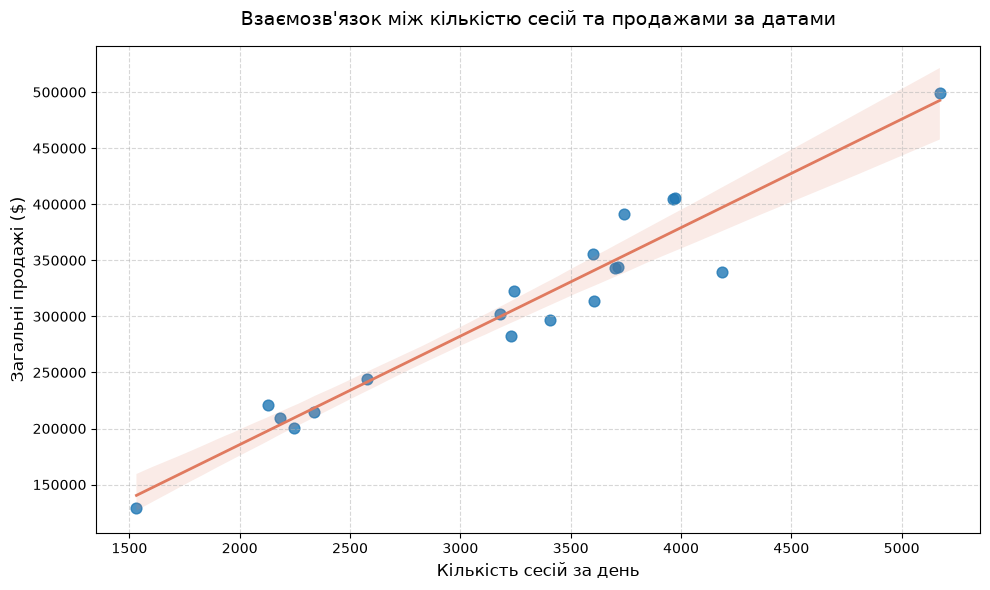

--- СТАТИСТИЧНИЙ АНАЛІЗ ЗВ'ЯЗКУ ---
Коефіцієнт кореляції Пірсона (r): 0.9655
p-value (Пірсон): 2.2815e-11
Коефіцієнт кореляції Спірмена (rho): 0.9246
p-value (Спірмен): 1.5380e-08


In [28]:
daily_metrics = df.groupby('session_date').agg(
    total_sessions=('ga_session_id', 'nunique'),
    total_sales=('price', 'sum')
).reset_index()

r_pearson, p_pearson = stats.pearsonr(daily_metrics['total_sessions'], daily_metrics['total_sales'])
r_spearman, p_spearman = stats.spearmanr(daily_metrics['total_sessions'], daily_metrics['total_sales'])

plt.figure(figsize=(10, 6))
sns.regplot(
    data=daily_metrics, 
    x='total_sessions', 
    y='total_sales', 
    color='#1f77b4',
    scatter_kws={'s': 60, 'alpha': 0.8},
    line_kws={'color': '#e07a5f', 'linewidth': 2}
)

plt.title('Взаємозв\'язок між кількістю сесій та продажами за датами', fontsize=14, pad=15)
plt.xlabel('Кількість сесій за день', fontsize=12)
plt.ylabel('Загальні продажі ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

print("--- СТАТИСТИЧНИЙ АНАЛІЗ ЗВ'ЯЗКУ ---")
print(f"Коефіцієнт кореляції Пірсона (r): {r_pearson:.4f}")
print(f"p-value (Пірсон): {p_pearson:.4e}")
print(f"Коефіцієнт кореляції Спірмена (rho): {r_spearman:.4f}")
print(f"p-value (Спірмен): {p_spearman:.4e}")

In [29]:
# ==========================================
# КРОК 6.2: Кореляція продажів між Топ-3 континентами
# ==========================================

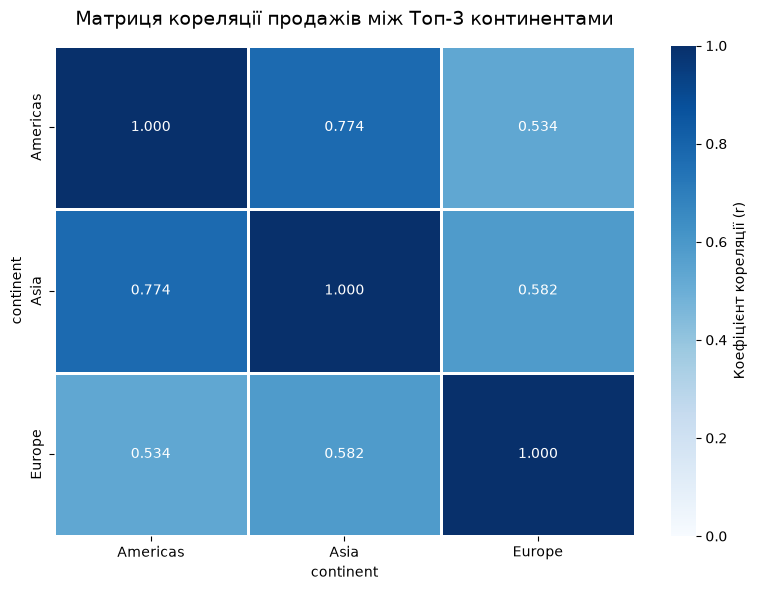

--- МАТРИЦЯ КОРЕЛЯЦІЇ (r) ---
continent  Americas    Asia  Europe
continent                          
Americas     1.0000  0.7741  0.5341
Asia         0.7741  1.0000  0.5824
Europe       0.5341  0.5824  1.0000

--- МАТРИЦЯ P-VALUE ---
continent Americas    Asia  Europe
continent                         
Americas    0.0000  0.0001  0.0185
Asia        0.0001  0.0000  0.0089
Europe      0.0185  0.0089  0.0000


In [30]:
top3_continents = ['Americas', 'Asia', 'Europe']
daily_continents_sales = df[df['continent'].isin(top3_continents)].pivot_table(
    index='session_date',
    columns='continent',
    values='price',
    aggfunc='sum'
).fillna(0)

corr_cont = daily_continents_sales.corr(method='pearson')

p_values_cont = pd.DataFrame(index=corr_cont.index, columns=corr_cont.columns)
for col1 in daily_continents_sales.columns:
    for col2 in daily_continents_sales.columns:
        _, p_val = stats.pearsonr(daily_continents_sales[col1], daily_continents_sales[col2])
        p_values_cont.loc[col1, col2] = p_val

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_cont, 
    annot=True, 
    fmt=".3f", 
    cmap='Blues', 
    vmin=0, 
    vmax=1, 
    linewidths=1,
    cbar_kws={'label': 'Коефіцієнт кореляції (r)'}
)

plt.title('Матриця кореляції продажів між Топ-3 континентами', fontsize=14, pad=15)
plt.tight_layout()

plt.show()

print("--- МАТРИЦЯ КОРЕЛЯЦІЇ (r) ---")
print(corr_cont.round(4))

print("\n--- МАТРИЦЯ P-VALUE ---")
print(p_values_cont.apply(lambda col: col.map('{:.4f}'.format)))

In [31]:
# ==========================================
# КРОК 6.3: Кореляція продажів між каналами трафіку
# ==========================================

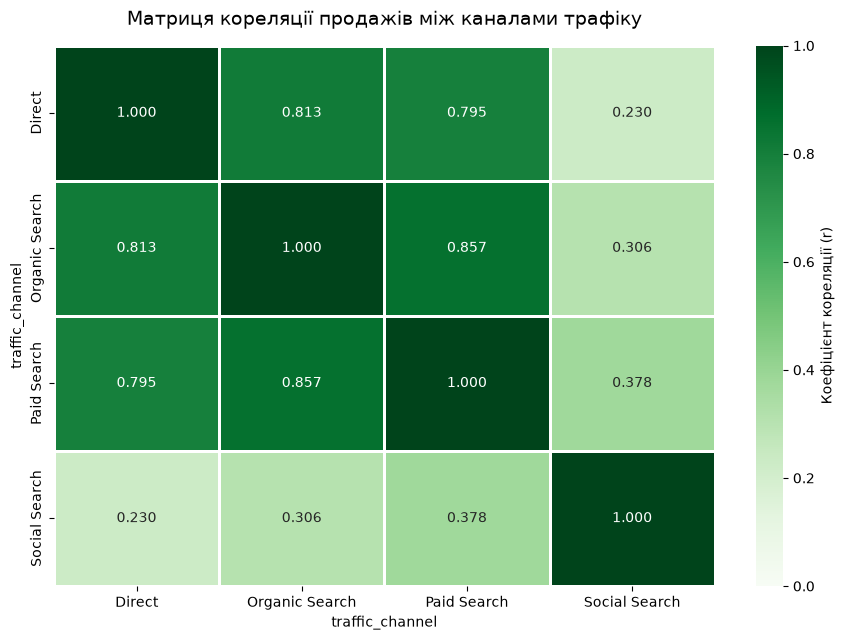

--- МАТРИЦЯ КОРЕЛЯЦІЇ (r) ---
traffic_channel  Direct  Organic Search  Paid Search  Social Search
traffic_channel                                                    
Direct           1.0000          0.8134       0.7954         0.2295
Organic Search   0.8134          1.0000       0.8566         0.3057
Paid Search      0.7954          0.8566       1.0000         0.3780
Social Search    0.2295          0.3057       0.3780         1.0000

--- МАТРИЦЯ P-VALUE ---
traffic_channel    Direct Organic Search Paid Search Social Search
traffic_channel                                                   
Direct           0.000000       0.000023    0.000047      0.344474
Organic Search   0.000023       0.000000    0.000003      0.203080
Paid Search      0.000047       0.000003    0.000000      0.110513
Social Search    0.344474       0.203080    0.110513      0.000000


In [32]:
main_channels = ['Organic Search', 'Paid Search', 'Direct', 'Social Search']
daily_channels_sales = df[df['traffic_channel'].isin(main_channels)].pivot_table(
    index='session_date',
    columns='traffic_channel',
    values='price',
    aggfunc='sum'
).fillna(0)

corr_chan = daily_channels_sales.corr(method='pearson')

p_values_chan = pd.DataFrame(index=corr_chan.index, columns=corr_chan.columns)
for col1 in daily_channels_sales.columns:
    for col2 in daily_channels_sales.columns:
        _, p_val = stats.pearsonr(daily_channels_sales[col1], daily_channels_sales[col2])
        p_values_chan.loc[col1, col2] = p_val

plt.figure(figsize=(9, 6.5))
sns.heatmap(
    corr_chan, 
    annot=True, 
    fmt=".3f", 
    cmap='Greens', 
    vmin=0, 
    vmax=1, 
    linewidths=1,
    cbar_kws={'label': 'Коефіцієнт кореляції (r)'}
)

plt.title('Матриця кореляції продажів між каналами трафіку', fontsize=14, pad=15)
plt.tight_layout()

plt.show()

print("--- МАТРИЦЯ КОРЕЛЯЦІЇ (r) ---")
print(corr_chan.round(4))

print("\n--- МАТРИЦЯ P-VALUE ---")
print(p_values_chan.apply(lambda col: col.map('{:.6f}'.format)))

In [33]:
# ==========================================
# КРОК 6.4: Кореляція продажів між Топ-5 категоріями товарів
# ==========================================

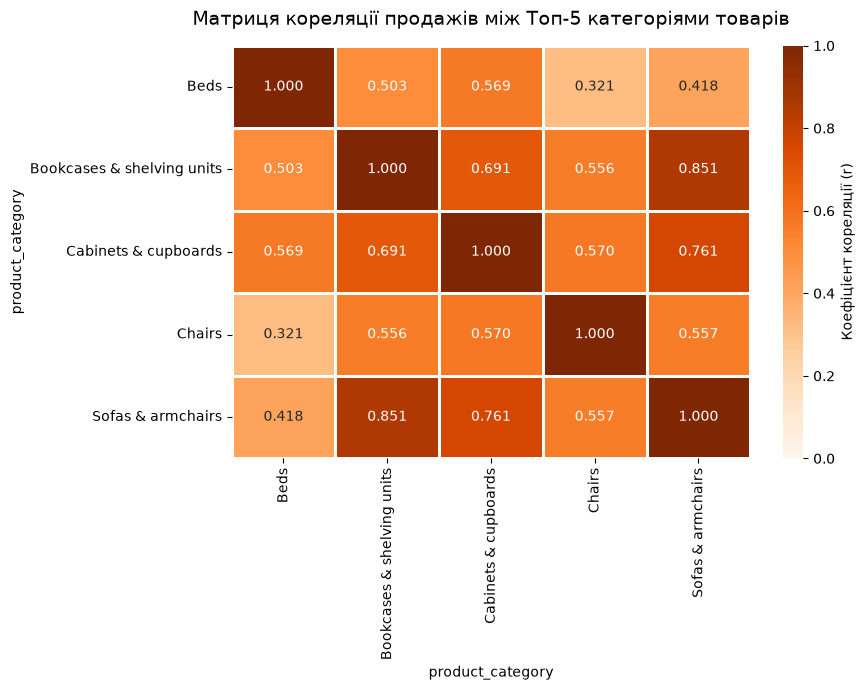

--- МАТРИЦЯ КОРЕЛЯЦІЇ (r) ---
product_category              Beds  Bookcases & shelving units  \
product_category                                                 
Beds                        1.0000                      0.5032   
Bookcases & shelving units  0.5032                      1.0000   
Cabinets & cupboards        0.5688                      0.6906   
Chairs                      0.3207                      0.5564   
Sofas & armchairs           0.4177                      0.8506   

product_category            Cabinets & cupboards  Chairs  Sofas & armchairs  
product_category                                                             
Beds                                      0.5688  0.3207             0.4177  
Bookcases & shelving units                0.6906  0.5564             0.8506  
Cabinets & cupboards                      1.0000  0.5704             0.7607  
Chairs                                    0.5704  1.0000             0.5568  
Sofas & armchairs                      

In [34]:
top5_cats = df.groupby('product_category')['price'].sum().nlargest(5).index.tolist()

daily_cats_sales = df[df['product_category'].isin(top5_cats)].pivot_table(
    index='session_date',
    columns='product_category',
    values='price',
    aggfunc='sum'
).fillna(0)

corr_cats = daily_cats_sales.corr(method='pearson')

p_values_cats = pd.DataFrame(index=corr_cats.index, columns=corr_cats.columns)
for col1 in daily_cats_sales.columns:
    for col2 in daily_cats_sales.columns:
        _, p_val = stats.pearsonr(daily_cats_sales[col1], daily_cats_sales[col2])
        p_values_cats.loc[col1, col2] = p_val

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_cats, 
    annot=True, 
    fmt=".3f", 
    cmap='Oranges', 
    vmin=0, 
    vmax=1, 
    linewidths=1,
    cbar_kws={'label': 'Коефіцієнт кореляції (r)'}
)

plt.title('Матриця кореляції продажів між Топ-5 категоріями товарів', fontsize=14, pad=15)
plt.tight_layout()

plt.show()

print("--- МАТРИЦЯ КОРЕЛЯЦІЇ (r) ---")
print(corr_cats.round(4))

print("\n--- МАТРИЦЯ P-VALUE ---")
print(p_values_cats.apply(lambda col: col.map('{:.6f}'.format)))

In [35]:
# ==========================================
# КРОК 6.5: Додатковий аналіз взаємозв'язків (Desktop vs Mobile та Замовлення vs AOV)
# ==========================================

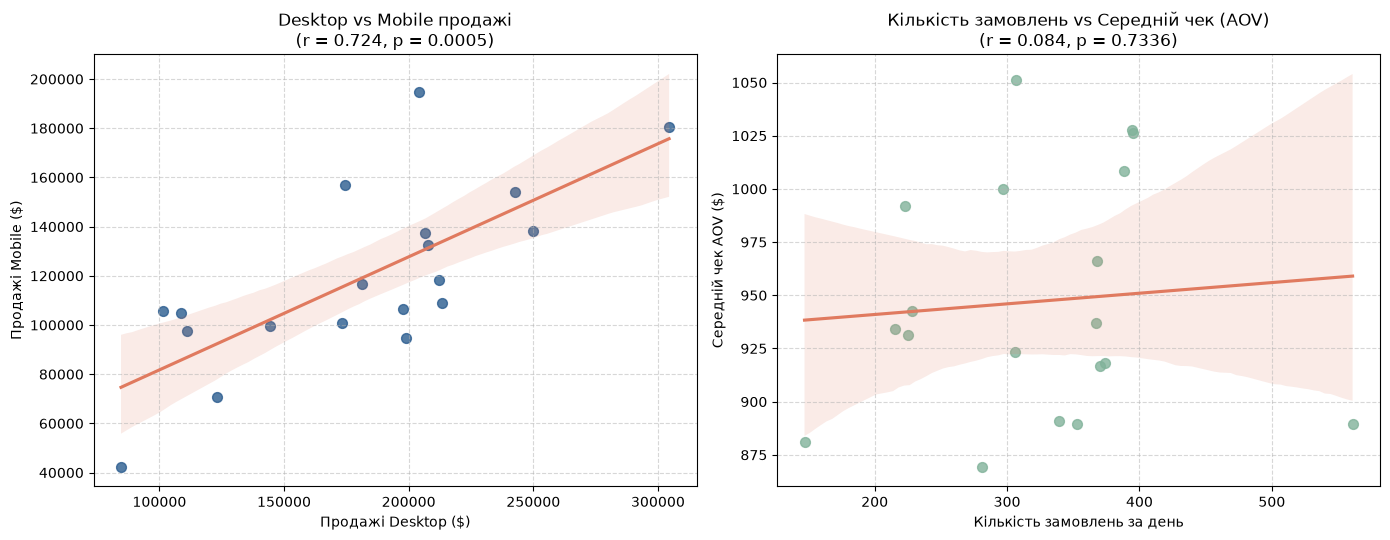

--- СТАТИСТИКА ДОДАТКОВИХ ВЗАЄМОЗВ'ЯЗКІВ ---
1. Desktop vs Mobile: r = 0.7244, p-value = 0.000452 (Статистично значуще)
2. Замовлення vs AOV: r = 0.0836, p-value = 0.7336 (НЕ значуще)


In [36]:
daily_devices = df.pivot_table(
    index='session_date',
    columns='device_type',
    values='price',
    aggfunc='sum'
).fillna(0)

r_dev, p_dev = stats.pearsonr(daily_devices['desktop'], daily_devices['mobile'])

# 2. Формуємо дані для перевірки залежності між кількістю замовлень та середнім чеком (AOV)
daily_aov = df[df['price'].notnull()].groupby('session_date').agg(
    orders_count=('price', 'count'),
    aov=('price', 'mean')
).reset_index()

r_aov, p_aov = stats.pearsonr(daily_aov['orders_count'], daily_aov['aov'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.regplot(
    data=daily_devices, 
    x='desktop', 
    y='mobile', 
    ax=axes[0], 
    color='#2b5c8f',
    scatter_kws={'s': 50},
    line_kws={'color': '#e07a5f'}
)
axes[0].set_title(f'Desktop vs Mobile продажі\n(r = {r_dev:.3f}, p = {p_dev:.4f})', fontsize=12)
axes[0].set_xlabel('Продажі Desktop ($)')
axes[0].set_ylabel('Продажі Mobile ($)')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.regplot(
    data=daily_aov, 
    x='orders_count', 
    y='aov', 
    ax=axes[1], 
    color='#81b29a',
    scatter_kws={'s': 50},
    line_kws={'color': '#e07a5f'}
)
axes[1].set_title(f'Кількість замовлень vs Середній чек (AOV)\n(r = {r_aov:.3f}, p = {p_aov:.4f})', fontsize=12)
axes[1].set_xlabel('Кількість замовлень за день')
axes[1].set_ylabel('Середній чек AOV ($)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("--- СТАТИСТИКА ДОДАТКОВИХ ВЗАЄМОЗВ'ЯЗКІВ ---")
print(f"1. Desktop vs Mobile: r = {r_dev:.4f}, p-value = {p_dev:.6f} (Статистично значуще)")
print(f"2. Замовлення vs AOV: r = {r_aov:.4f}, p-value = {p_aov:.4f} (НЕ значуще)")


In [37]:
# ==========================================
# КРОК 7.1: Статистичний аналіз: Зареєстровані vs Незареєстровані користувачі
# ==========================================

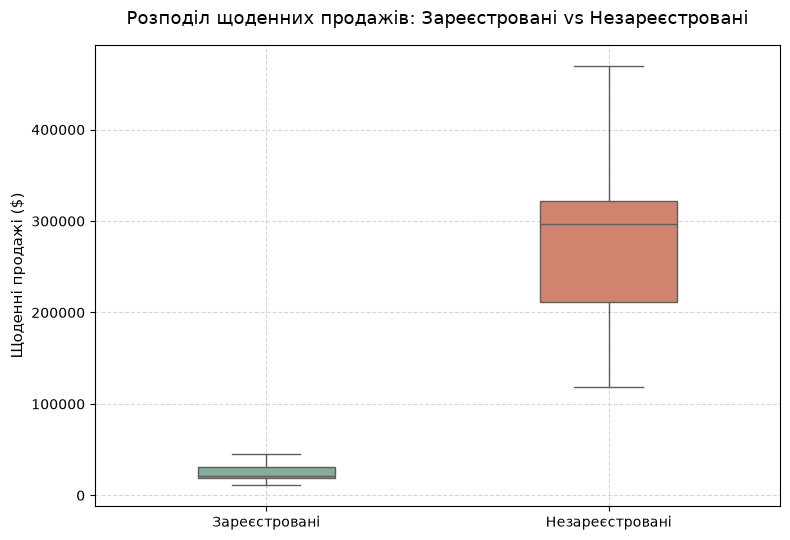

--- СЕРЕДНІ ЗНАЧЕННЯ ---
Середні щоденні продажі (Зареєстровані): 25,438.11 $
Середні щоденні продажі (Незареєстровані): 280,942.25 $

--- ТЕСТ НА НОРМАЛЬНІСТЬ (Шапіро-Уїлк) ---
Зареєстровані: p-value = 0.0288
Незареєстровані: p-value = 0.8352

--- КРИТЕРІЙ МАННА-УЇТНІ ---
U-статистика: 0.0
p-value: 1.4798e-07


In [38]:
reg_sales_daily = df[df['user_id'].notnull()].groupby('session_date')['price'].sum()
non_reg_sales_daily = df[df['user_id'].isnull()].groupby('session_date')['price'].sum()

daily_users_df = pd.DataFrame({
    'Зареєстровані': reg_sales_daily,
    'Незареєстровані': non_reg_sales_daily
}).fillna(0)

stat_reg, p_norm_reg = stats.shapiro(daily_users_df['Зареєстровані'])
stat_non_reg, p_norm_non_reg = stats.shapiro(daily_users_df['Незареєстровані'])

mwu_stat, p_value_mwu = stats.mannwhitneyu(
    daily_users_df['Зареєстровані'], 
    daily_users_df['Незареєстровані'], 
    alternative='two-sided'
)

plt.figure(figsize=(8, 5.5))
sns.boxplot(data=daily_users_df, palette=['#81b29a', '#e07a5f'], width=0.4)

plt.title('Розподіл щоденних продажів: Зареєстровані vs Незареєстровані', fontsize=13, pad=15)
plt.ylabel('Щоденні продажі ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("--- СЕРЕДНІ ЗНАЧЕННЯ ---")
print(f"Середні щоденні продажі (Зареєстровані): {daily_users_df['Зареєстровані'].mean():,.2f} $")
print(f"Середні щоденні продажі (Незареєстровані): {daily_users_df['Незареєстровані'].mean():,.2f} $\n")

print("--- ТЕСТ НА НОРМАЛЬНІСТЬ (Шапіро-Уїлк) ---")
print(f"Зареєстровані: p-value = {p_norm_reg:.4f}")
print(f"Незареєстровані: p-value = {p_norm_non_reg:.4f}\n")

print("--- КРИТЕРІЙ МАННА-УЇТНІ ---")
print(f"U-статистика: {mwu_stat}")
print(f"p-value: {p_value_mwu:.4e}")

In [39]:
# ==========================================
# КРОК 7.2: Статистичний аналіз: Кількість сесій за каналами трафіку
# ==========================================

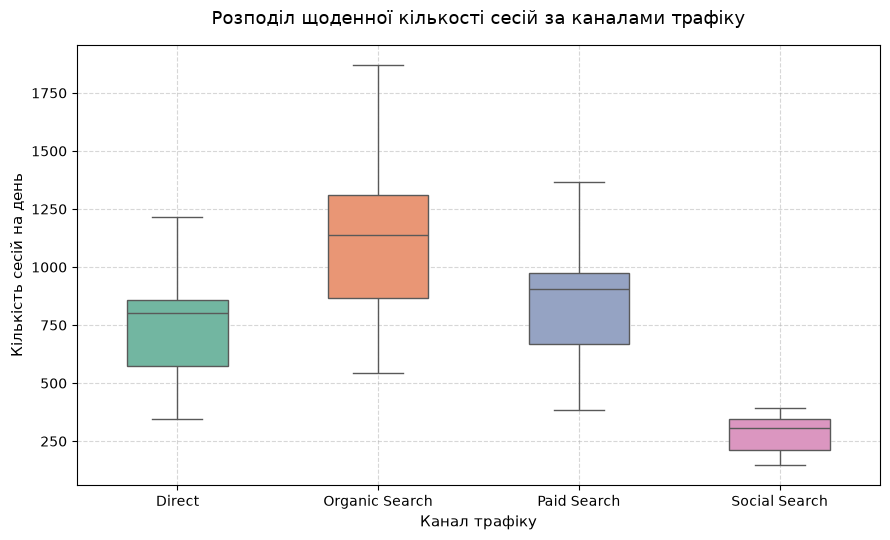

--- СЕРЕДНЯ ЩОДЕННА КІЛЬКІСТЬ СЕСІЙ ---
traffic_channel
Direct             752.11
Organic Search    1120.89
Paid Search        850.05
Social Search      284.79

--- ТЕСТ КРАСКЕЛА-УОЛЛІСА (Kruskal-Wallis H-test) ---
H-статистика: 49.2737
p-value: 1.1407e-10


In [40]:
channels_list = ['Organic Search', 'Paid Search', 'Direct', 'Social Search']
daily_sessions_channel = df[df['traffic_channel'].isin(channels_list)].pivot_table(
    index='session_date',
    columns='traffic_channel',
    values='ga_session_id',
    aggfunc='nunique'
).fillna(0)

stat_kw, p_val_kw = stats.kruskal(
    daily_sessions_channel['Organic Search'],
    daily_sessions_channel['Paid Search'],
    daily_sessions_channel['Direct'],
    daily_sessions_channel['Social Search']
)

plt.figure(figsize=(9, 5.5))
sns.boxplot(data=daily_sessions_channel, palette='Set2', width=0.5)

plt.title('Розподіл щоденної кількості сесій за каналами трафіку', fontsize=13, pad=15)
plt.ylabel('Кількість сесій на день', fontsize=11)
plt.xlabel('Канал трафіку', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("--- СЕРЕДНЯ ЩОДЕННА КІЛЬКІСТЬ СЕСІЙ ---")
print(daily_sessions_channel.mean().round(2).to_string())

print("\n--- ТЕСТ КРАСКЕЛА-УОЛЛІСА (Kruskal-Wallis H-test) ---")
print(f"H-статистика: {stat_kw:.4f}")
print(f"p-value: {p_val_kw:.4e}")

In [41]:
# ==========================================
# КРОК 7.3: Перевірка частки органічного трафіку (Europe vs Americas)
# ==========================================

In [42]:
df_eu_am = df[df['continent'].isin(['Europe', 'Americas'])].copy()

df_eu_am['is_organic'] = df_eu_am['traffic_channel'] == 'Organic Search'

contingency_table = pd.crosstab(df_eu_am['continent'], df_eu_am['is_organic'])
contingency_table.columns = ['Інший трафік', 'Organic Search']

chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)

organic_pct = (contingency_table['Organic Search'] / contingency_table.sum(axis=1) * 100).round(2)

print("--- ТАБЛИЦЯ СПРЯЖЕНОСТІ СЕСІЙ ---")
print(contingency_table)

print("\n--- ЧАСТКА ОРГАНІЧНОГО ТРАФІКУ (%) ---")
print(organic_pct.to_string())

print("\n--- КРИТЕРІЙ ХІ-КВАДРАТ (Chi-Square Test) ---")
print(f"Chi2-статистика: {chi2_stat:.4f}")
print(f"p-value: {p_val_chi2:.4f}")

--- ТАБЛИЦЯ СПРЯЖЕНОСТІ СЕСІЙ ---
           Інший трафік  Organic Search
continent                              
Americas          22352           11688
Europe             7458            3969

--- ЧАСТКА ОРГАНІЧНОГО ТРАФІКУ (%) ---
continent
Americas    34.34
Europe      34.73

--- КРИТЕРІЙ ХІ-КВАДРАТ (Chi-Square Test) ---
Chi2-статистика: 0.5811
p-value: 0.4459


In [43]:
# ==========================================
# КРОК 7.4: Додатковий статистичний тест: Середній чек (Desktop vs Mobile)
# ==========================================

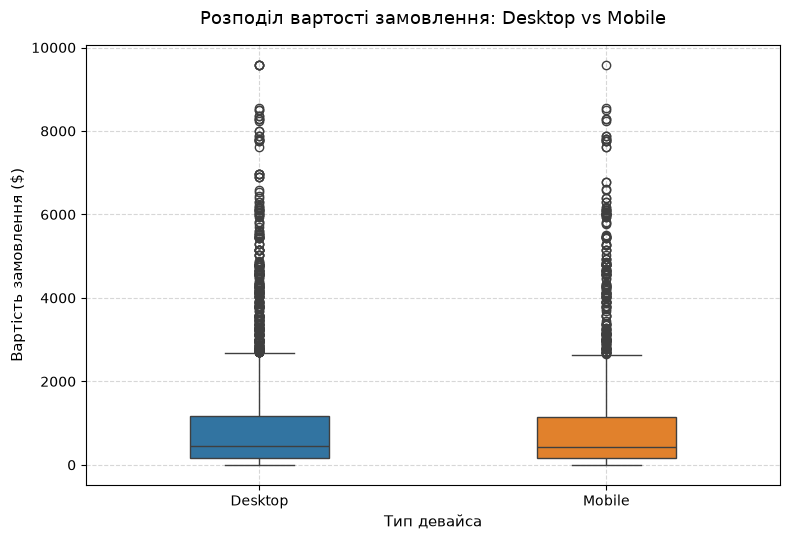

--- СЕРЕДНІ ЧЕКИ ТА МЕДІАНИ ---
Desktop: Середнє = 941.39 $, Медіана = 445.00 $
Mobile:  Середнє = 956.49 $, Медіана = 425.00 $

--- КРИТЕРІЙ МАННА-УЇТНІ ---
U-статистика: 4313068.0
p-value: 0.9279


In [44]:
df_orders_dev = df[df['device_type'].isin(['desktop', 'mobile']) & df['price'].notnull()].copy()

desktop_orders = df_orders_dev[df_orders_dev['device_type'] == 'desktop']['price']
mobile_orders = df_orders_dev[df_orders_dev['device_type'] == 'mobile']['price']

mwu_dev_stat, p_val_dev_mwu = stats.mannwhitneyu(desktop_orders, mobile_orders, alternative='two-sided')

plt.figure(figsize=(8, 5.5))
sns.boxplot(
    data=df_orders_dev, 
    x='device_type', 
    y='price', 
    hue='device_type',
    palette=['#1f77b4', '#ff7f0e'], 
    legend=False,
    width=0.4
)

plt.xticks([0, 1], ['Desktop', 'Mobile'])
plt.title('Розподіл вартості замовлення: Desktop vs Mobile', fontsize=13, pad=15)
plt.xlabel('Тип девайса', fontsize=11)
plt.ylabel('Вартість замовлення ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Вивід результатів
print("--- СЕРЕДНІ ЧЕКИ ТА МЕДІАНИ ---")
print(f"Desktop: Середнє = {desktop_orders.mean():,.2f} $, Медіана = {desktop_orders.median():,.2f} $")
print(f"Mobile:  Середнє = {mobile_orders.mean():,.2f} $, Медіана = {mobile_orders.median():,.2f} $\n")

print("--- КРИТЕРІЙ МАННА-УЇТНІ ---")
print(f"U-статистика: {mwu_dev_stat}")
print(f"p-value: {p_val_dev_mwu:.4f}")

In [45]:
# ==========================================
# КРОК 8: Експорт очищеного датасету для Tableau Public
# ==========================================

In [46]:
export_filename = 'portfolio_dataset_tableau.csv'

df.to_csv(export_filename, index=False)

print(f"--- ФАЙЛ УСПІШНО ЗБЕРЕЖЕНО ---")
print(f"Назва файлу: {export_filename}")
print(f"Кількість рядків: {len(df):,}")
print(f"Кількість колонок: {len(df.columns)}")
print(f"\nПерелік колонок для Tableau:\n{list(df.columns)}")

--- ФАЙЛ УСПІШНО ЗБЕРЕЖЕНО ---
Назва файлу: portfolio_dataset_tableau.csv
Кількість рядків: 61,712
Кількість колонок: 18

Перелік колонок для Tableau:
['session_date', 'ga_session_id', 'continent', 'country', 'device_type', 'browser', 'device_model', 'operating_system', 'browser_language', 'traffic_source', 'traffic_channel', 'user_id', 'is_email_confirmed', 'is_unsubscribed', 'product_category', 'product_name', 'price', 'product_description']
